In [276]:
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [226]:
import struct

# https://web.archive.org/web/20200722154330/http://yann.lecun.com/exdb/mnist/#:~:text=FILE%20FORMATS

# https://docs.python.org/3/library/struct.html

def read_idx_images(filename):
    with open(filename, 'rb') as f:
        magic = struct.unpack('>I', f.read(4))[0]
        assert magic == 2051, f"Invalid magic number for images: {magic}"
        num_images = struct.unpack('>I', f.read(4))[0]
        rows = struct.unpack('>I', f.read(4))[0]
        cols = struct.unpack('>I', f.read(4))[0]
        images = []
        for _ in range(num_images):
            image = []
            for _ in range(rows):
                row = []
                for _ in range(cols):
                    pixel = struct.unpack('>B', f.read(1))[0]
                    row.append(pixel)
                image.append(row)
            images.append(image)
        return images

def read_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic = struct.unpack('>I', f.read(4))[0]
        assert magic == 2049, f"Invalid magic number for labels: {magic}"
        num_labels = struct.unpack('>I', f.read(4))[0]
        labels = [struct.unpack('>B', f.read(1))[0]
                  for _ in range(num_labels)]
        return labels

In [227]:
train_images = read_idx_images(f"mnist/train-images-idx3-ubyte")
train_labels = read_idx_labels(f"mnist/train-labels-idx1-ubyte")
test_images = read_idx_images(f"mnist/t10k-images-idx3-ubyte")
test_labels = read_idx_labels(f"mnist/t10k-labels-idx1-ubyte")

In [228]:
def display(image):
    plt.figure(figsize=(1, 1))
    plt.axis('off')
    plt.imshow(image)

5

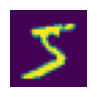

In [229]:
display(train_images[0])
train_labels[0]

7

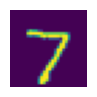

In [230]:
display(test_images[0])
test_labels[0]

In [231]:
LABELS = sorted(set(train_labels))
LABELS

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [232]:
len(LABELS)

10

In [233]:
INPUTS = 28 * 28
INPUTS

784

In [234]:
import torch
import torch.nn.functional as F

In [423]:
W = torch.randn((784, 10), requires_grad=True)

In [236]:
xs = torch.tensor([[pixel/255 for row in img for pixel in row] for img in train_images])

In [237]:
xs.shape, xs.dtype, xs.max().item(), xs.min().item(), f"{xs.mean().item():.4f}"

(torch.Size([60000, 784]), torch.float32, 1.0, 0.0, '0.1307')

In [238]:
ys = torch.tensor(train_labels)

In [239]:
ys.shape, ys.dtype, ys.max().item(), ys.min().item()

(torch.Size([60000]), torch.int64, 9, 0)

In [240]:
xs.shape, W.shape

(torch.Size([60000, 784]), torch.Size([784, 10]))

In [502]:
EPOCHS = 1000
STEP = 0.9

In [503]:
for k in range(EPOCHS):
    logits = xs @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    loss = (
        -probs[torch.arange(xs.shape[0]), ys].log().mean()
            + 1.4*(W**2).mean()
    )
    if k%200==0: print(f"loss: {loss.item():.4f}")
    W.grad = None
    loss.backward()
    W.data -= STEP * W.grad
print(f"loss: {loss.item():.4f}")

loss: 0.3935
loss: 0.3815
loss: 0.3712
loss: 0.3621
loss: 0.3543
loss: 0.3475


In [250]:
test_xs = torch.tensor([[pixel/255 for row in img for pixel in row] for img in test_images])
test_ys = torch.tensor(test_labels)

In [504]:
test_logits = test_xs @ W
test_counts = test_logits.exp()
test_probs = test_counts / test_counts.sum(1, keepdims=True)
test_loss = -test_probs[torch.arange(test_xs.shape[0]), test_ys].log().mean()
f"test loss: {test_loss.item():.4f}"

'test loss: 0.2771'

('i=7992', 2, 2)

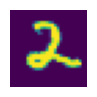

In [565]:
i = random.randint(0, len(test_labels))
display(test_images[i])
f"{i=}", (torch.tensor([[pixel/255 for row in img for pixel in row] for img in test_images[i:i+1]]) @ W).argmax().item(), test_labels[i]